STAGE 1

In [58]:
students = {
    "Ravi": [85,90,78],
    "Meena":[92,88,95],
    "Arjun":[60,55,70]
}
print(students)

{'Ravi': [85, 90, 78], 'Meena': [92, 88, 95], 'Arjun': [60, 55, 70]}


In [59]:
for name in students:
    marks = students[name]
    average = sum(marks)/len(marks)
    if average >= 70:
        result = "Pass"
    else:
            result = "Fail"
    print(name,average,result)

Ravi 84.33333333333333 Pass
Meena 91.66666666666667 Pass
Arjun 61.666666666666664 Fail


In [60]:
highest_average = 0
topper = ""

for name in students:
    marks = students[name]
    average = sum(marks)/len(marks)
    
    if average > highest_average:
        highest_average=average
        topper = name
print("Topper:",topper,"with average",highest_average)


Topper: Meena with average 91.66666666666667


In [61]:
lowest_average = 1000
weakest = ""

for name in students:
    marks =students[name]
    average = sum(marks)/len(marks)

    if average < lowest_average:
        lowest_average = average 
        weakest = name
print ("Needs support:",weakest,"with average",lowest_average)

Needs support: Arjun with average 61.666666666666664


STAGE 2

In [62]:
import pandas as pd

df=pd.read_csv("students.csv")
print(df)

    Name  Math  Science  English
0   Ravi    85     90.0       78
1  Meena    92     88.0       95
2  Arjun    60     55.0       70
3  Divya    45      NaN       40
4  Kiran    75     80.0       72
5  Sneha    88     92.0       85
6  Rahul    55     60.0       58
7  Priya    95     90.0       98


In [63]:
df = pd.read_csv("students.csv")
print(df["Science"])

0    90.0
1    88.0
2    55.0
3     NaN
4    80.0
5    92.0
6    60.0
7    90.0
Name: Science, dtype: float64


here df_filled is used to fillvalues anywhere in the data frame.here we only have missing value in science so its not a problem.


In [64]:
df["Science"]=df["Science"].fillna(df["Science"].mean())
print(df["Science"])

0    90.000000
1    88.000000
2    55.000000
3    79.285714
4    80.000000
5    92.000000
6    60.000000
7    90.000000
Name: Science, dtype: float64


In [65]:
print(df.isnull().sum())

Name       0
Math       0
Science    0
English    0
dtype: int64


In [66]:
df["Average"]=df[["Math","Science","English"]].mean(axis=1)
df["Result"]=df["Average"].apply(lambda avg: "Pass" if avg >= 70 else "Fail" )
print(df)

    Name  Math    Science  English    Average Result
0   Ravi    85  90.000000       78  84.333333   Pass
1  Meena    92  88.000000       95  91.666667   Pass
2  Arjun    60  55.000000       70  61.666667   Fail
3  Divya    45  79.285714       40  54.761905   Fail
4  Kiran    75  80.000000       72  75.666667   Pass
5  Sneha    88  92.000000       85  88.333333   Pass
6  Rahul    55  60.000000       58  57.666667   Fail
7  Priya    95  90.000000       98  94.333333   Pass


STAGE 3

In [67]:
pass_count=(df["Result"]=="Pass").sum()
print(pass_count)

5


In [68]:
total_students=len(df)
pass_percentage=(pass_count/total_students)*100
print(pass_percentage)

62.5


to know subject wise performance

In [69]:
subject_averages = df[["Math","Science","English"]].mean()
print(subject_averages)

Math       74.375000
Science    79.285714
English    74.500000
dtype: float64


In [70]:
strongest_subject=subject_averages.idxmax()
weakest_subject=subject_averages.idxmin()

print("Strongest subject",strongest_subject)
print("Weakest subject",weakest_subject)

Strongest subject Science
Weakest subject Math


In [71]:
ranked = df.sort_values(by="Average",ascending=False)
print(ranked)

    Name  Math    Science  English    Average Result
7  Priya    95  90.000000       98  94.333333   Pass
1  Meena    92  88.000000       95  91.666667   Pass
5  Sneha    88  92.000000       85  88.333333   Pass
0   Ravi    85  90.000000       78  84.333333   Pass
4  Kiran    75  80.000000       72  75.666667   Pass
2  Arjun    60  55.000000       70  61.666667   Fail
6  Rahul    55  60.000000       58  57.666667   Fail
3  Divya    45  79.285714       40  54.761905   Fail


STAGE 4

Matplotlib

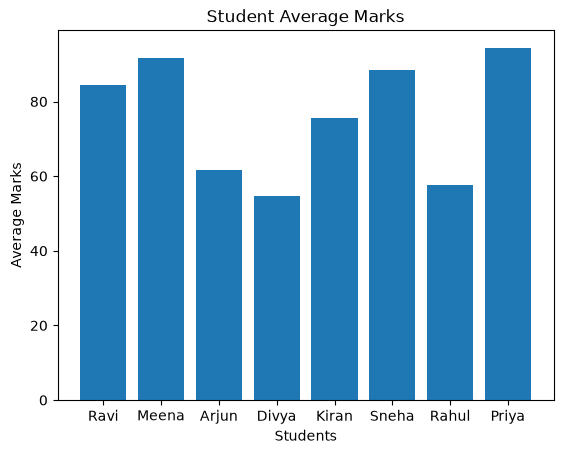

In [72]:
import matplotlib.pyplot as plt
plt.bar(df["Name"],df["Average"])
plt.xlabel("Students")
plt.ylabel("Average Marks")
plt.title("Student Average Marks")
plt.show()

Subject wise comparison chart

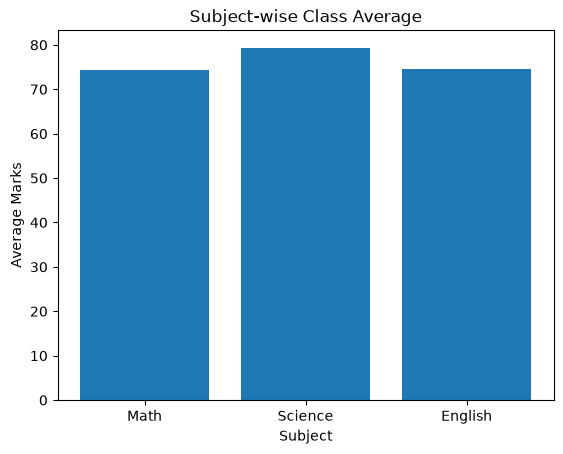

In [73]:
subject_averages=df[["Math","Science","English"]].mean()
plt.bar(subject_averages.index,subject_averages.values)
plt.xlabel("Subject")
plt.ylabel("Average Marks")
plt.title("Subject-wise Class Average")
plt.show()

Seaborn

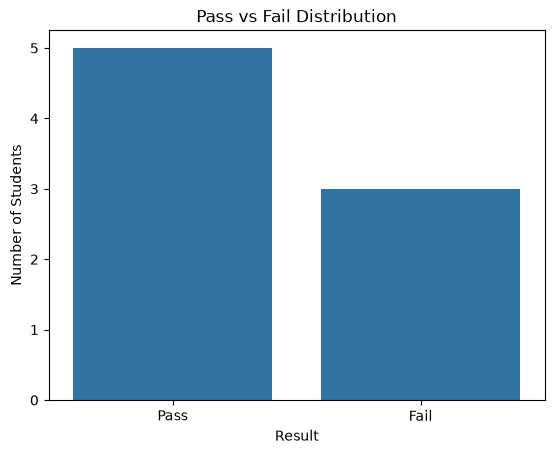

In [74]:
import seaborn as sns
sns.countplot(x="Result",data=df)
plt.xlabel("Result")
plt.ylabel("Number of Students")
plt.title("Pass vs Fail Distribution")
plt.show()

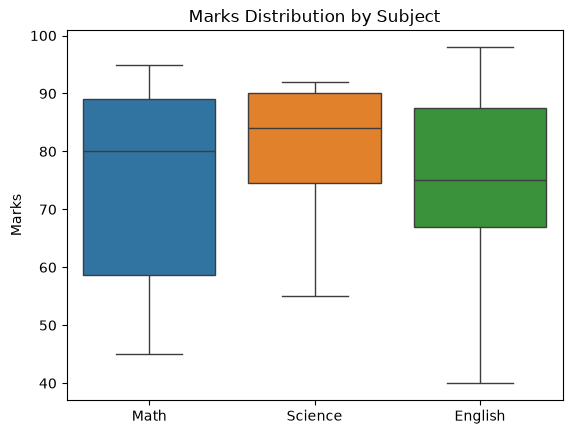

In [75]:
sns.boxplot(data=df[["Math","Science","English"]])
plt.ylabel("Marks")
plt.title("Marks Distribution by Subject")
plt.show()

STAGE 5

Seperate features from target

In [76]:
X = df[["Math","Science","English"]]
y=df["Result"]

print(X)
print(y)

   Math    Science  English
0    85  90.000000       78
1    92  88.000000       95
2    60  55.000000       70
3    45  79.285714       40
4    75  80.000000       72
5    88  92.000000       85
6    55  60.000000       58
7    95  90.000000       98
0    Pass
1    Pass
2    Fail
3    Fail
4    Pass
5    Pass
6    Fail
7    Pass
Name: Result, dtype: str


Train/test split

In [77]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.25,random_state=42)
print(X_train)
print(X_test)

   Math    Science  English
0    85  90.000000       78
7    95  90.000000       98
2    60  55.000000       70
4    75  80.000000       72
3    45  79.285714       40
6    55  60.000000       58
   Math  Science  English
1    92     88.0       95
5    88     92.0       85


Use logistic regression and train the model

In [78]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train,y_train)
print("Model Trained")

Model Trained


Prediction

In [79]:
predictions = model.predict(X_test)
print("Predicted:",list(predictions))
print("Actual:",list(y_test))

Predicted: ['Pass', 'Pass']
Actual: ['Pass', 'Pass']


In [80]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y_test,predictions)
print("Accuracy",accuracy)

Accuracy 1.0


STAGE 6-portfolio version-simple user interface

Get student name from user

In [81]:
name = input("Enter student name")
print("Student:",name)

Student: Roobika


Get subject marks from the user

In [82]:
math_mark=int(input("Enter Math Mark:"))
science_mark=int(input("Enter Science mark:"))
english_mark=int(input("Enter English mark:"))

print("Math:",math_mark)
print("Science:",science_mark)
print("English:",english_mark)

Math: 88
Science: 87
English: 78


Prediction using trained model

In [83]:
new_student=pd.DataFrame([[math_mark,science_mark,english_mark]],columns=["Math","Science","English"])
prediction = model.predict(new_student)
print(name,"is predicted to:",prediction[0])

Roobika is predicted to: Pass
